# 1) Быстрый обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('laptop_price.csv', encoding='latin-1')

print(f"Формат данных: {df.shape}")
display(df.head())
display(df.info())
display(df.describe())
display(df.describe(include="object"))

print(f"Дубликатов: {df.duplicated().sum()}")
print(df.isnull().sum())

Формат данных: (1303, 13)


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


None

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


,Company,Product,TypeName,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1303,1303,1303,1303,1303,1303,1303,1303,1303,1303
unique,19,618,6,40,118,9,39,110,9,179
top,Dell,XPS 13,Notebook,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,297,30,727,507,190,619,412,281,1072,121


Дубликатов: 0
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


# 2) Очистка и предобработка

In [2]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

df['Price_euros'] = df['Price_euros'].fillna(df['Price_euros'].median())

screen_mode = df['ScreenResolution'].mode()[0]
df['ScreenResolution'] = df['ScreenResolution'].fillna(screen_mode)

print("Данные очищены. Типы приведены к числовым.")

Данные очищены. Типы приведены к числовым.


# 3) Расширенная статистика
Здесь мы считаем моменты распределения.

In [3]:
from scipy.stats import skew, kurtosis

stats = {
    "Min": df['Price_euros'].min(),
    "Max": df['Price_euros'].max(),
    "Mean": df['Price_euros'].mean(),
    "Median": df['Price_euros'].median(),
    "Mode": df['Price_euros'].mode()[0],
    "Var (Дисперсия)": df['Price_euros'].var(),
    "Skewness (Асимметрия)": df['Price_euros'].skew(),
    "Kurtosis (Эксцесс)": df['Price_euros'].kurtosis()
}

percentiles = df['Price_euros'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

print("Статистика цен:", stats)
print("Перцентили:", percentiles)

Статистика цен: {'Min': np.float64(174.0), 'Max': np.float64(6099.0), 'Mean': np.float64(1123.6869915579432), 'Median': np.float64(977.0), 'Mode': np.float64(1099.0), 'Var (Дисперсия)': np.float64(488613.64154393773), 'Skewness (Асимметрия)': np.float64(1.5208655681688525), 'Kurtosis (Эксцесс)': np.float64(4.371086279272811)}
Перцентили: 0.05     309.00
0.25     599.00
0.50     977.00
0.75    1487.88
0.95    2448.60
Name: Price_euros, dtype: float64


# 4) Feature Engineering

In [4]:
df_encoded = pd.get_dummies(df, columns=['TypeName'], prefix='Type')

from sklearn.feature_extraction import FeatureHasher
hasher = FeatureHasher(n_features=5, input_type='string')
cpu_hashed = hasher.transform(df['Cpu'].apply(lambda x: [x])).toarray()
df_hashed = pd.concat([df_encoded, pd.DataFrame(cpu_hashed, columns=[f'cpu_h{i}' for i in range(5)])], axis=1)

df['Price_per_GB_Ram'] = df['Price_euros'] / df['Ram']
df['Is_UltraLight'] = df['Weight'].apply(lambda x: 1 if x < 1.5 else 0)

display(df[['Company', 'Price_per_GB_Ram', 'Is_UltraLight']].head())

,Company,Price_per_GB_Ram,Is_UltraLight
0,Apple,167.461250,1
1,Apple,112.367500,1
2,HP,71.875000,0
3,Apple,158.590625,0
4,Apple,225.450000,1


# 5) Визуализация

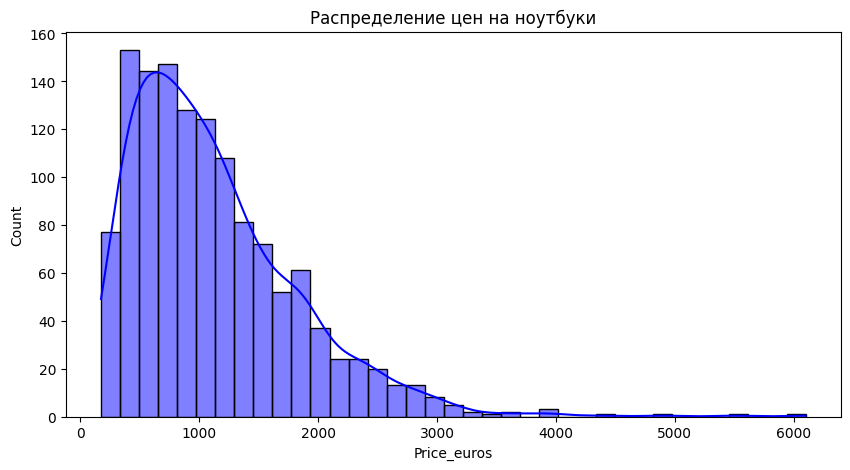

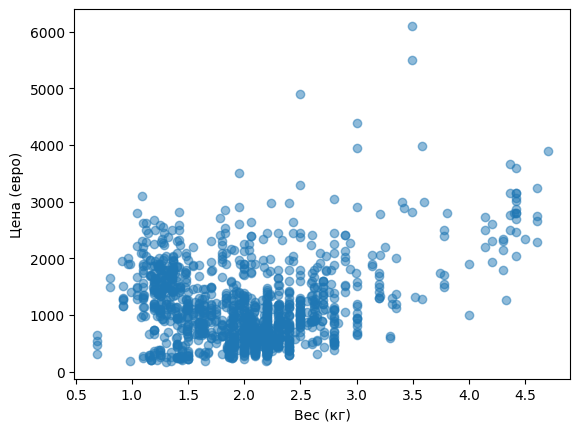

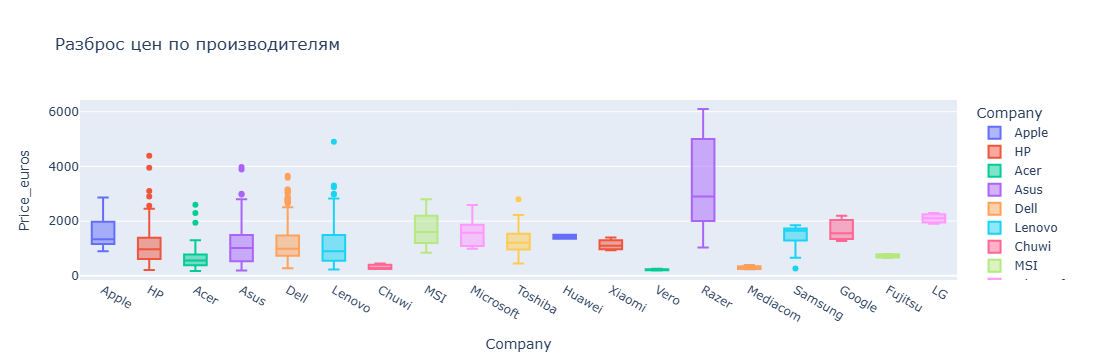

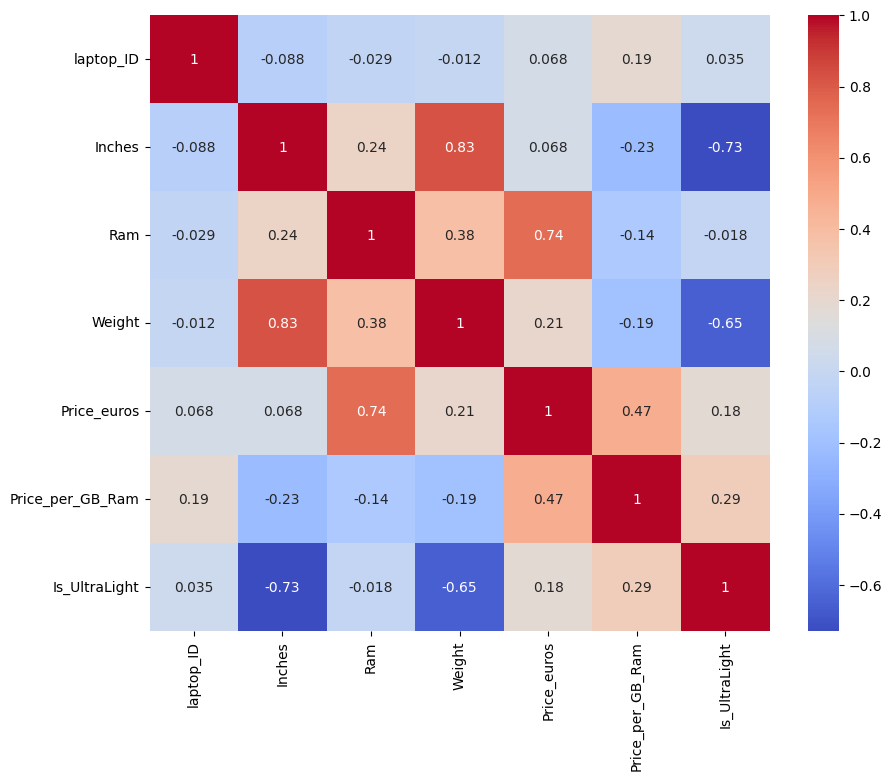

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_euros'], kde=True, color='blue')
plt.title('Распределение цен на ноутбуки')
plt.show()

plt.scatter(df['Weight'], df['Price_euros'], alpha=0.5)
plt.xlabel('Вес (кг)')
plt.ylabel('Цена (евро)')
plt.show()

fig = px.box(df, x="Company", y="Price_euros", color="Company", 
             title="Разброс цен по производителям", hover_data=['Cpu', 'Ram'])
fig.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()

# Итоговые выводы
## Что я понял про датасет:

Данные содержат 1303 записи о ноутбуках.

Самые дорогие бренды — Razer, Apple и LG (в топовых комплектациях).

Распределение цен имеет положительную асимметрию (Skewness), что логично: бюджетных моделей больше, чем люксовых.

Объем оперативной памяти (Ram) имеет самую сильную корреляцию с ценой.

Вес ноутбука слабо коррелирует с ценой напрямую, но ультрабуки часто стоят дороже средних моделей.

Многие колонки требуют предварительной очистки от строковых символов (GB, kg).

Большинство ноутбуков на рынке имеют разрешение Full HD (1920x1080).

Гипотезы:

Цена и тип: Ноутбуки типа "Workstation" и "Gaming" в среднем в 2 раза дороже, чем "Notebook".

Эффект бренда: У бренда Apple нет "бюджетного" сегмента (минимум выше 800 евро), в отличие от HP или Lenovo.

Выбросы: Высокие значения цен в игровых ноутбуках вызваны мощными GPU, которые мы закодировали хэшированием.

Что делать дальше:
Я бы построил модель Random Forest Regressor, чтобы предсказывать цену. Также стоит детальнее распарсить колонку Cpu, выделив частоту процессора как отдельное число.

Работа с AI:

Использовал подсказки для написания регулярных выражений при очистке Ram и Weight.

Уточнял синтаксис FeatureHasher.

Вручную проверял корректность графиков Plotly и добавлял hover_data для информативности